## 支持向量机（SVM）——能做什么？

一句话：**SVM 是一种强大的监督学习模型，主要用于分类，也能做回归和异常检测**。它在小样本、非线性、高维数据上表现尤其突出。

---

### 1. 最核心用途：分类

- **二分类**：SVM 最初就是为了解决二分类问题设计的。它找出一个**最优超平面**（决策边界），使得不同类别之间的**间隔最大化**。
  **例子**：判断邮件是正常还是垃圾邮件；医学影像判断肿瘤恶性/良性；手写数字识别（用“一对多”策略可做多分类）。

- **多分类**：通过“一对一”（OvO）或“一对多”（OvR）策略扩展为多分类器。

#### 优势场景
- **特征维度 > 样本数**（如基因数据、文本分类）
  SVM 不太受维度灾难影响，只要选择合适正则化。
- **数据线性不可分** → 使用**核技巧**（如 RBF 核）映射到高维空间，自动学习复杂边界。
- **小样本**：SVM 泛化能力强，不易过拟合（依赖支持向量，而非全部样本）。

---

### 2. 回归（SVR）

- **支持向量回归**：不追求误差最小化，而是让预测值落在某个“容忍带”内（ε-不敏感）。
  **例子**：股票价格预测、空气质量指数预测、房价预测。

---

### 3. 异常检测（One‑Class SVM）

- 仅用正常数据训练，识别新样本是否“异常”。
  **例子**：信用卡欺诈检测、网络入侵检测、工业设备故障预警。

---

### 4. 为什么 SVM 曾经非常火？

- **理论优美**：基于结构风险最小化（不同于神经网络的经验风险最小化），对小样本泛化有理论保证。
- **核技巧**：可以隐式地将数据映射到无穷维空间，而不增加计算量。
- **凸优化**：解是全局唯一最优解，不会陷入局部最优。

---

### 5. 当前的局限（与深度学习相比）

- **大数据不适用**：传统 SVM 训练复杂度 O(n²) ~ O(n³) ，百万级数据训练极慢。
- **核选择依赖经验**：RBF 等核的参数（C，gamma）需要调优。
- **不适合图像、语音等原始高维信号**（深度学习完胜）。

---

## 📌 总结表格

| 任务类型 | 是否适用 | 典型场景 |
|---------|----------|-----------|
| **二分类** | ✅ 非常擅长 | 文本分类、蛋白质功能预测 |
| **多分类** | ✅ 可用（OvR/OvO）| 手写数字、物品识别 |
| **回归** | ✅（SVR） | 连续值预测（小样本） |
| **异常检测** | ✅（One‑Class）| 欺诈/入侵检测 |
| **图像分类（原始像素）** | ❌ 效果差 | 现代 CNN 主导 |
| **超大数据集（>10万样本）** | ❌ 训练慢 | 用神经网络或近似SVM（如线性SVM） |

---

## 一句话记忆
> **SVM 是“小样本、高维度、非线性分类”的利器，但别拿它硬刚大数据和原始图像。**

如果你需要，我可以给你一个用 sklearn 实现 SVM 二分类 + RBF 核的代码例子。

训练集准确率: 1.000
测试集准确率: 1.000
新样本 [0.5 0.5] 的预测类别: 1


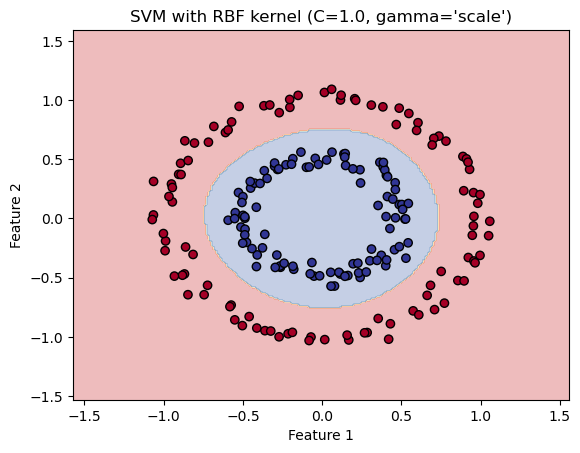

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. 生成非线性可分的二维数据（两个同心圆）
X, y = make_circles(n_samples=200, noise=0.05, factor=0.5, random_state=42)
# y 已经是 0/1 标签

# 2. 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. 特征标准化（SVM 对尺度敏感，必须做）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. 创建 SVM 分类器（RBF 核）
#    - C: 正则化参数，越小对误分类容忍度越高（希望更平滑的边界）
#    - gamma: RBF 核的系数，决定单个样本的影响范围
svm_clf = svm.SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_clf.fit(X_train_scaled, y_train)

# 5. 评估模型
train_acc = svm_clf.score(X_train_scaled, y_train)
test_acc = svm_clf.score(X_test_scaled, y_test)
print(f"训练集准确率: {train_acc:.3f}")
print(f"测试集准确率: {test_acc:.3f}")

# 6. 对新样本进行预测（举例）
new_sample = np.array([[0.5, 0.5]])   # 两个特征值
new_sample_scaled = scaler.transform(new_sample)
pred = svm_clf.predict(new_sample_scaled)
print(f"新样本 {new_sample[0]} 的预测类别: {pred[0]}")

# ========== 可选：可视化决策边界 ==========
def plot_decision_boundary(clf, X, y, scaler, title="SVM Decision Boundary"):
    # 生成网格
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_scaled = scaler.transform(grid)
    Z = clf.predict(grid_scaled)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolors='k')
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

plot_decision_boundary(svm_clf, X, y, scaler, title=f"SVM with RBF kernel (C=1.0, gamma='scale')")

一、核函数的作用（为什么需要核？）
SVM 本质是求解一个线性分类超平面。当数据在原始空间中线性不可分时，我们可以通过一个映射函数 φ(x) 将数据从低维空间映射到高维特征空间，使其在高维空间中变得线性可分。
但直接计算 φ(x) 可能非常困难（甚至无穷维），核函数 K(x_i, x_j) = φ(x_i)·φ(x_j) 允许我们在不显式计算映射的情况下，直接得到高维空间中的内积，从而高效地训练 SVM。

总结
什么时候用 RBF 核 SVM？
数据维度中等（几十到几千）、样本量不大（< 5 万）、特征与标签之间的关系是非线性的。

必须做的预处理：特征标准化（因为 SVM 依赖距离或内积）。

调参核心：C 和 gamma，通常需要网格搜索。

三、什么情况下选择 RBF 核？
RBF 核是 SVM 的“万能核”，在多数实际问题中表现优异。推荐在以下情况优先尝试 RBF：

数据线性不可分（决策边界是曲线、环状、复杂形状）。

特征维数适中（几十到几千维）。若特征维数极高（如 >10⁴），线性核可能更快且效果不差。

样本量不大（几万以内）。RBF 核 SVM 训练复杂度 O(n²)~O(n³)，样本太多时速度慢。

没有先验知识选择其他核。不确定时，先用 RBF + 网格搜索调参 C、γ。

什么时候不用 RBF 核？

数据线性可分 → 用线性核更快，结果可解释性更好。

特征维数远大于样本数（如基因数据）→ 线性核通常已足够。

样本数超过 5 万 → 推荐线性核或近似核方法（如 Nystroem）。

In [ ]:
from sklearn import svm

# 1. 指定 kernel 参数
clf = svm.SVC(kernel='rbf')      # 使用 RBF 核
clf = svm.SVC(kernel='linear')   # 使用线性核
clf = svm.SVC(kernel='poly', degree=3, coef0=1)  # 多项式核
clf = svm.SVC(kernel='sigmoid')  # Sigmoid 核

# 2. 训练（自动计算核矩阵）
clf.fit(X_train, y_train)

# 3. 预测（同样基于核函数计算新样本与支持向量的内积）
y_pred = clf.predict(X_test)

重要参数（RBF 核）：

C：正则化强度。C 越大，训练集准确率越高，但可能过拟合。

gamma：γ 值，决定 RBF 核的“作用范围”。
gamma 越大 → 每个样本的影响范围越小，决策边界越曲折（易过拟合）；
gamma 越小 → 边界越平滑（可能欠拟合）。

常见设置：
γ = 1/(n_features × X.var())（gamma='scale'，sklearn 默认）或
γ = 1/n_features（gamma='auto'）。

## 五、理解 RBF 核的“非线性魔法”
距离度量：RBF 核只依赖于两个样本的欧氏距离 ‖x-z‖²。距离越近，核函数值越接近 1；距离越远，值趋近 0。

映射到无穷维：理论上，RBF 核对应的高维空间是无穷维的，因此总能找到线性可分的映射（只要适当选择 γ）。

局部性：RBF 核本质上是一种局部加权方法，每个支持向量只对附近区域产生强烈影响。

In [2]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1, 'scale']
}
svm = svm.SVC(kernel='rbf')
grid = GridSearchCV(svm, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_scaled, y_train)
print(grid.best_params_)

{'C': 0.1, 'gamma': 1}


观察规律：

若最佳 C 偏大（≥10），说明数据可能需要更复杂的边界。

若最佳 gamma 很大（≥1），说明决策边界非常局部，可能存在过拟合风险。

若最佳 gamma 很小（≤0.01），边界过于平滑，可尝试增加 C 或换其他核。